In [1]:
!pip install kaggle

In [2]:
from datasets import load_dataset

ds = load_dataset("uoft-cs/cifar10")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/120M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/23.9M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

# Importing the Dependecies

In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import matplotlib.image as mpimg

In [5]:
len(ds)

2

In [7]:
ds

DatasetDict({
    train: Dataset({
        features: ['img', 'label'],
        num_rows: 50000
    })
    test: Dataset({
        features: ['img', 'label'],
        num_rows: 10000
    })
})

In [8]:
print(ds['train'][1])

{'img': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=32x32 at 0x784E2640E240>, 'label': 6}


In [12]:
import pandas as pd

# Convert the 'label' column to a pandas Series and then use value_counts()
pd.Series(ds['train']['label']).value_counts().sort_index()

,count
0,5000
1,5000
2,5000
3,5000
4,5000
5,5000
6,5000
7,5000
8,5000
9,5000


In [13]:
dic = {0:'airplane',
       1:'automobile',
       2:'bird',
       3:'cat',
       4:'deer',
       5:'dog',
       6:'frog',
       7:'horse',
       8:'ship',
       9:'truck'}

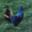

In [20]:
import cv2
from google.colab.patches import cv2_imshow
import numpy as np

# Access the PIL Image object directly and convert to a NumPy array
img_pil = ds['train'][5]['img']
img_np = np.array(img_pil)

cv2_imshow(img_np)

In [28]:
# convert images to numpy array

images = []
labels = []


In [23]:
for item in ds['train']:
    img_np = np.array(item['img'])
    images.append(img_np)
    labels.append(item['label'])

print(f"Number of images processed: {len(images)}")
print(f"Number of labels processed: {len(labels)}")

Number of images processed: 50000
Number of labels processed: 50000


**Reasoning**:
The subtask of iterating and processing the dataset has been completed. Now I will display a sample image and its corresponding label to confirm successful conversion and storage as part of the overall task.



Displaying sample image at index 0


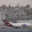

Label: 0 (airplane)


In [24]:
sample_index = 0
print(f"Displaying sample image at index {sample_index}")

# Display the image using cv2_imshow
cv2_imshow(images[sample_index])

# Print the label of the displayed image
print(f"Label: {labels[sample_index]} ({dic[labels[sample_index]]})")

In [26]:
x_train = np.array(images)
y_train = np.array(labels)

In [27]:
x_train.shape, y_train.shape

((50000, 32, 32, 3), (50000,))

In [29]:
img2 = []
label2 = []
for item in ds['test']:
    img_np = np.array(item['img'])
    img2.append(img_np)
    label2.append(item['label'])

In [30]:
x_test = np.array(img2)
y_test = np.array(label2)

In [32]:
x_test.shape, y_train.shape

((10000, 32, 32, 3), (50000,))

In [34]:
print(y_test[:5])

[3 8 8 0 6]


Building the Neural Network

In [37]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

In [39]:
no_classes = 10
input_shape = (32,32,3)

# setting up the layers of neural network
model = keras.Sequential([
    keras.layers.Flatten(input_shape=input_shape),
    keras.layers.Dense(512, activation='relu'),
    keras.layers.Dense(256, activation='relu'),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dense(no_classes, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [40]:
# compile the nn

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [43]:
# train our model
model.fit(x_train, y_train, validation_split=0.1, epochs=20)

Epoch 1/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.0976 - loss: 2.3028 - val_accuracy: 0.0898 - val_loss: 2.3027
Epoch 2/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.0995 - loss: 2.3028 - val_accuracy: 0.0898 - val_loss: 2.3029
Epoch 3/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.0986 - loss: 2.3027 - val_accuracy: 0.0966 - val_loss: 2.3029
Epoch 4/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.0994 - loss: 2.3028 - val_accuracy: 0.0898 - val_loss: 2.3030
Epoch 5/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.0973 - loss: 2.3028 - val_accuracy: 0.1026 - val_loss: 2.3026
Epoch 6/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.0983 - loss: 2.3028 - val_accuracy: 0.1010 - val_loss: 2.3026
Epoch 7/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.0981 - loss: 2.3028 - val_accuracy: 0.1010 - val_loss: 2.3029
Epoch 8/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.0978 - loss: 2.3028 - 

# Restnet50

In [44]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras import models
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.resnet50 import ResNet50
from tensorflow.keras import optimizers

In [51]:
convolutional_base = ResNet50(weights='imagenet', include_top=False, input_shape=(256,256,3))
convolutional_base.summary()

Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 262, 262,  │          0 │ input_layer_3[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 128, 128,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 128, 128,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 128, 128,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 130, 130,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 64, 64,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 64, 64,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 64, 64,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 64, 64,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 64, 64,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 64, 64,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 64, 64,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 64, 64,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 64, 64,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 64, 64,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 64, 64,    │      1,024 │ conv2_block1_3_c

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 23,534,592 (89.78 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [52]:
no_classes = 10

model2 = models.Sequential()
model2.add(layers.UpSampling2D((2,2)))
model2.add(layers.UpSampling2D((2,2)))
model2.add(layers.UpSampling2D((2,2)))
model2.add(convolutional_base)
model2.add(layers.Flatten())
model2.add(layers.BatchNormalization())
model2.add(layers.Dense(256, activation='relu'))
model2.add(layers.Dropout(0.5))
model2.add(layers.BatchNormalization())
model2.add(layers.Dense(128, activation='relu'))
model2.add(layers.Dropout(0.5))
model2.add(layers.BatchNormalization())
model2.add(layers.Dense(64, activation='relu'))
model2.add(layers.Dropout(0.5))
model2.add(layers.BatchNormalization())
model2.add(layers.Dense(no_classes, activation='softmax'))

In [53]:
model2.compile(
    optimizer=optimizers.RMSprop(learning_rate=2e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [55]:
history = model2.fit(x_train, y_train, validation_split=0.1, epochs=10)

Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 561s 369ms/step - accuracy: 0.2824 - loss: 2.1366 - val_accuracy: 0.6778 - val_loss: 1.1494
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 490s 348ms/step - accuracy: 0.5092 - loss: 1.4772 - val_accuracy: 0.8462 - val_loss: 0.6477
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 490s 348ms/step - accuracy: 0.6743 - loss: 1.0799 - val_accuracy: 0.8952 - val_loss: 0.4471
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 490s 348ms/step - accuracy: 0.7715 - loss: 0.8427 - val_accuracy: 0.9108 - val_loss: 0.3516
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 490s 348ms/step - accuracy: 0.8387 - loss: 0.6594 - val_accuracy: 0.9322 - val_loss: 0.2741
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 490s 348ms/step - accuracy: 0.8808 - loss: 0.5238 - val_accuracy: 0.9368 - val_loss: 0.2530
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 489s 348ms/step - accuracy: 0.9125 - loss: 0.4241 - val_accuracy: 0.9388 - val_loss: 0.2273
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 490s 348ms/step - ac

In [57]:
import numpy as np
from sklearn.metrics import accuracy_score

y_pred = model2.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)

accuracy = accuracy_score(y_test, y_pred_classes)
print("Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 44s 114ms/step
Accuracy: 0.9452


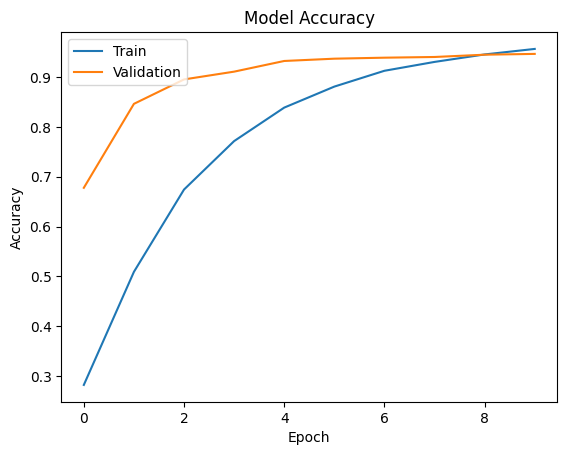

In [58]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.show()

In [59]:
print("Training Accuracy:", history.history['accuracy'][-1])
print("Validation Accuracy:", history.history['val_accuracy'][-1])

Training Accuracy: 0.9563778042793274
Validation Accuracy: 0.946399986743927
